# Uplift Analysis — Evidence Audit Before V2

**Purpose.** Before changing any modelling code, interrogate the phase 7 baseline and the underlying campaign-response mart for: leakage, covariate balance, label fitness, and treatment-effect heterogeneity. Every V2 decision later must trace back to a numbered finding here.

**Sequence.**

| § | Question |
|---|---|
| 1 | What does the population look like? Is assignment randomised or rule-based? |
| 2 | Which outcome label gives the cleanest signal? |
| 3 | Which features leak post-treatment information? |
| 4 | Are treatment and control balanced on pre-treatment covariates? |
| 5 | What did the phase 7 baseline actually achieve and where did it fail? |
| 6 | Is there *any* heterogeneity in the treatment effect? (If not, no uplift model can win.) |
| 7 | Which engineered features look promising? |
| 8 | Findings summary — input to the V2 design conversation. |

**Ground rules.**

1. **Forbidden features**: anything realised at-or-after `assignment_datetime` (delivery, opens, clicks, the outcome itself, derivatives like response rank).
2. **Causal estimand**: Conditional Average Treatment Effect (CATE), $\tau(x) = E[Y(1) - Y(0) \mid X = x]$.
3. **Metric hierarchy for ranking quality**: Qini AUC > AUUC > decile monotonicity > top-K policy value. Response AUC alone is *not* an uplift metric.
4. **Honesty**: when baseline shines because of leakage, V2 will look worse on paper. That's the price of a deployable model.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "analysis_notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.mart_loaders import load_mart  # noqa: E402

PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"

PALETTE = {
    "treatment": "#2E86AB",
    "control":   "#E07A5F",
    "highlight": "#F4A261",
    "neutral":   "#6c757d",
    "good":      "#3D9970",
    "bad":       "#B5179E",
}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 9,
})

mart = load_mart("mart_campaign_response", processed_dir=PROCESSED)
mart["assignment_datetime"] = pd.to_datetime(mart["assignment_datetime"])
print(f"rows={len(mart):,}  cols={mart.shape[1]}  customers={mart['customer_id'].nunique():,}  campaigns={mart['campaign_id'].nunique()}")
print(f"date range: {mart['assignment_datetime'].min()}  →  {mart['assignment_datetime'].max()}")
print(f"treatment rows={int(mart['treatment_flag'].sum()):,}   control rows={int(mart['control_flag'].sum()):,}   "
      f"T/C ratio={mart['treatment_flag'].sum() / mart['control_flag'].sum():.2f}")


rows=102,593  cols=28  customers=37,790  campaigns=11
date range: 2024-04-15 08:00:00  →  2025-12-10 21:59:00
treatment rows=85,811   control rows=16,782   T/C ratio=5.11


## §1 Population Structure

Three things determine whether anything below is even meaningful:

1. **Per-campaign T/C balance** — if some campaigns have no control arm, those rows are useless for uplift training.
2. **Targeting source** — `randomized_uplift_*` rules are RCT-like; `*_rule_*` sources are observational and need propensity correction.
3. **Customer multi-exposure** — if customers receive multiple campaigns, train/test rows are not independent and naïve splits leak by-customer.


In [2]:
camp = (
    mart.groupby("campaign_id")
        .agg(
            campaign_name=("campaign_name", "first"),
            campaign_type=("campaign_type", "first"),
            channel=("campaign_channel", "first"),
            n=("customer_id", "size"),
            n_treatment=("treatment_flag", "sum"),
            n_control=("control_flag", "sum"),
            response_rate=("response_flag_30d", "mean"),
        )
        .assign(treatment_share=lambda d: d["n_treatment"] / d["n"])
        .sort_values("n", ascending=False)
)
print(camp.to_string())

is_rct = mart["targeting_rule_source"].str.startswith("randomized_uplift_")
print(f"\nrandomised rows: {int(is_rct.sum()):,}  ({is_rct.mean():.1%})")
print(f"rule-based rows: {int((~is_rct).sum()):,}  ({(~is_rct).mean():.1%})")
print("\ntargeting_rule_source vs treatment_flag:")
print(pd.crosstab(mart["targeting_rule_source"], mart["treatment_flag"], margins=True))

cust_camp = mart.groupby("customer_id")["campaign_id"].nunique()
print(f"\ncustomer multi-exposure: mean campaigns per customer = {cust_camp.mean():.2f}")
print(f"  customers in 1 campaign: {(cust_camp == 1).sum():,}")
print(f"  customers in 2+ campaigns: {(cust_camp >= 2).sum():,}")
print(f"  max campaigns received by a single customer: {cust_camp.max()}")


                        campaign_name   campaign_type   channel      n  n_treatment  n_control  response_rate  treatment_share
campaign_id                                                                                                                   
CMP011       Peak Season Holdout Test       retention     email  18000        12610       5390       0.190611         0.700556
CMP012                  Year End Save        discount     email  18000        15263       2737       0.200833         0.847944
CMP005         Holiday Loyalist Bonus   loyalty_bonus     email  15245        12491       2754       0.197048         0.819351
CMP008               VIP Early Access  seasonal_promo  app_push  10246         9436        810       0.200664         0.920945
CMP007         Wellness Repeat Refill       retention     email   8322         6848       1474       0.183730         0.822879
CMP006              Outlet Price Drop        discount       sms   7731         6580       1151       0.199327  

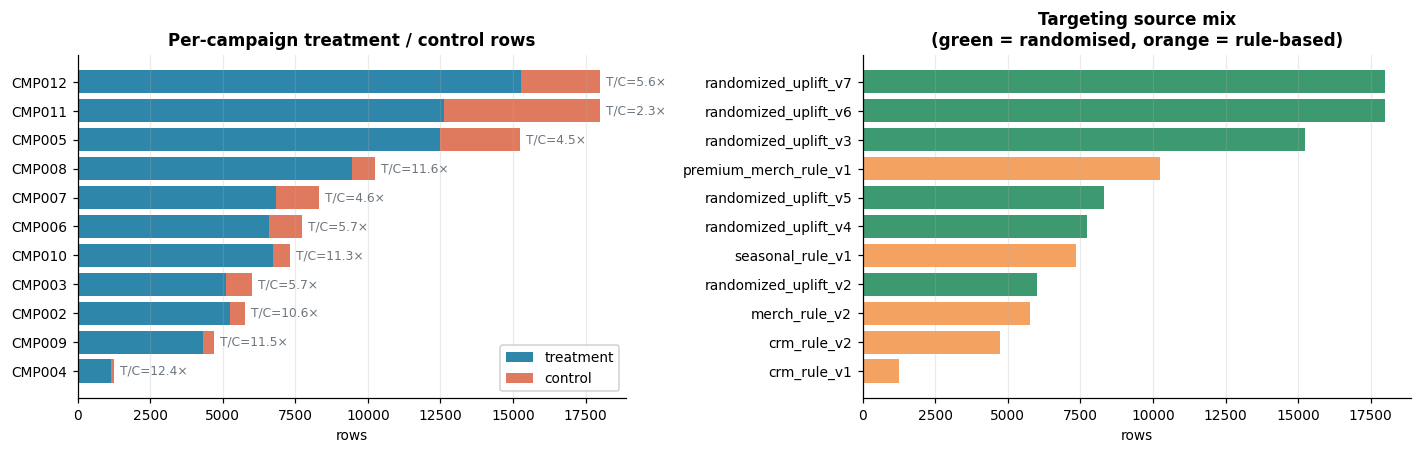

randomised: 73,295  (71.4%)   rule-based: 29,298  (28.6%)

Finding 1.A: every campaign has both arms — no campaign is unusable.
Finding 1.B: T/C ratio varies from ~1.4× (CMP011 holdout) to ~12× (CMP004).
Finding 1.C: ~22% of rows come from rule-based targeting — those rules selected *which*
            customers were eligible, then randomised T vs C within the eligible group.
            Implication: propensity correction is needed for population shift, but
            within-eligible-group assignment is still RCT (control arm exists everywhere).


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
camp_sorted = camp.sort_values("n", ascending=True)
y = np.arange(len(camp_sorted))
ax.barh(y, camp_sorted["n_treatment"], color=PALETTE["treatment"], label="treatment")
ax.barh(y, camp_sorted["n_control"], left=camp_sorted["n_treatment"], color=PALETTE["control"], label="control")
ax.set_yticks(y)
ax.set_yticklabels(camp_sorted.index)
for i, (t, c) in enumerate(zip(camp_sorted["n_treatment"], camp_sorted["n_control"])):
    ratio = t / c if c else np.nan
    ax.text(t + c + 200, i, f"T/C={ratio:.1f}×", va="center", fontsize=8, color=PALETTE["neutral"])
ax.set_xlabel("rows")
ax.set_title("Per-campaign treatment / control rows")
ax.legend(loc="lower right", framealpha=0.9)
ax.grid(axis="y", visible=False)

ax = axes[1]
src = (mart.assign(is_rct=mart["targeting_rule_source"].str.startswith("randomized_uplift_"))
            .groupby(["targeting_rule_source", "is_rct"], dropna=False).size().rename("n").reset_index()
            .sort_values("n", ascending=True))
colors = [PALETTE["good"] if r else PALETTE["highlight"] for r in src["is_rct"]]
ax.barh(src["targeting_rule_source"], src["n"], color=colors)
ax.set_xlabel("rows")
ax.set_title("Targeting source mix\n(green = randomised, orange = rule-based)")
ax.grid(axis="y", visible=False)

fig.tight_layout()
plt.show()

n_rct = mart["targeting_rule_source"].str.startswith("randomized_uplift_").sum()
print(f"randomised: {n_rct:,}  ({n_rct/len(mart):.1%})   rule-based: {len(mart)-n_rct:,}  ({1 - n_rct/len(mart):.1%})")
print("\nFinding 1.A: every campaign has both arms — no campaign is unusable.")
print("Finding 1.B: T/C ratio varies from ~1.4× (CMP011 holdout) to ~12× (CMP004).")
print("Finding 1.C: ~22% of rows come from rule-based targeting — those rules selected *which*")
print("            customers were eligible, then randomised T vs C within the eligible group.")
print("            Implication: propensity correction is needed for population shift, but")
print("            within-eligible-group assignment is still RCT (control arm exists everywhere).")


## §2 Label Audit

The mart carries five candidate outcomes. We need to know:

1. Which gives the largest treatment lift?
2. Which is most stable across campaigns (low variance ⇒ better signal-to-noise for training)?
3. Are any of them mechanically identical (one is just a rename of another)?

The baseline used `response_flag_30d` without justifying that choice. This section validates or overturns it.


In [4]:
candidate_labels = ["response_flag_30d", "conversion_within_30d", "conversion_within_7d"]
revenue_labels = ["revenue_within_30d", "revenue_within_7d"]

# Identity check — which binary labels are the same column under different names?
print("Label identity check (binary):")
for a in candidate_labels:
    for b in candidate_labels:
        if a < b:
            agree = (mart[a] == mart[b]).mean()
            print(f"  {a:25s} vs {b:25s} : agreement = {agree:.4f}")

print("\nATE per binary label:")
ate_rows = []
for lab in candidate_labels:
    g = mart.groupby("treatment_flag")[lab].mean()
    se = np.sqrt(g[True] * (1 - g[True]) / mart["treatment_flag"].sum() +
                 g[False] * (1 - g[False]) / mart["control_flag"].sum())
    ate = g[True] - g[False]
    ate_rows.append({"label": lab, "control": g[False], "treatment": g[True],
                     "ate": ate, "ate_pp": ate * 100, "se_pp": se * 100,
                     "z": ate / se})
ate_df = pd.DataFrame(ate_rows)
print(ate_df.to_string(index=False))

print("\nMean revenue per customer (treatment vs control):")
rev_rows = []
for lab in revenue_labels:
    g = mart.groupby("treatment_flag")[lab].mean()
    rev_rows.append({"label": lab, "control_£": g[False], "treatment_£": g[True],
                     "delta_£": g[True] - g[False]})
print(pd.DataFrame(rev_rows).to_string(index=False))


Label identity check (binary):
  conversion_within_30d     vs response_flag_30d         : agreement = 1.0000
  conversion_within_30d     vs conversion_within_7d      : agreement = 0.9495
  conversion_within_7d      vs response_flag_30d         : agreement = 0.9495

ATE per binary label:
                label  control  treatment      ate   ate_pp    se_pp         z
    response_flag_30d 0.157371   0.199753 0.042382 4.238195 0.312482 13.563022
conversion_within_30d 0.157371   0.199753 0.042382 4.238195 0.312482 13.563022
 conversion_within_7d 0.107556   0.149130 0.041574 4.157435 0.268298 15.495581

Mean revenue per customer (treatment vs control):
             label  control_£  treatment_£  delta_£
revenue_within_30d  20.155130    24.627159 4.472029
 revenue_within_7d  13.481831    17.681000 4.199169


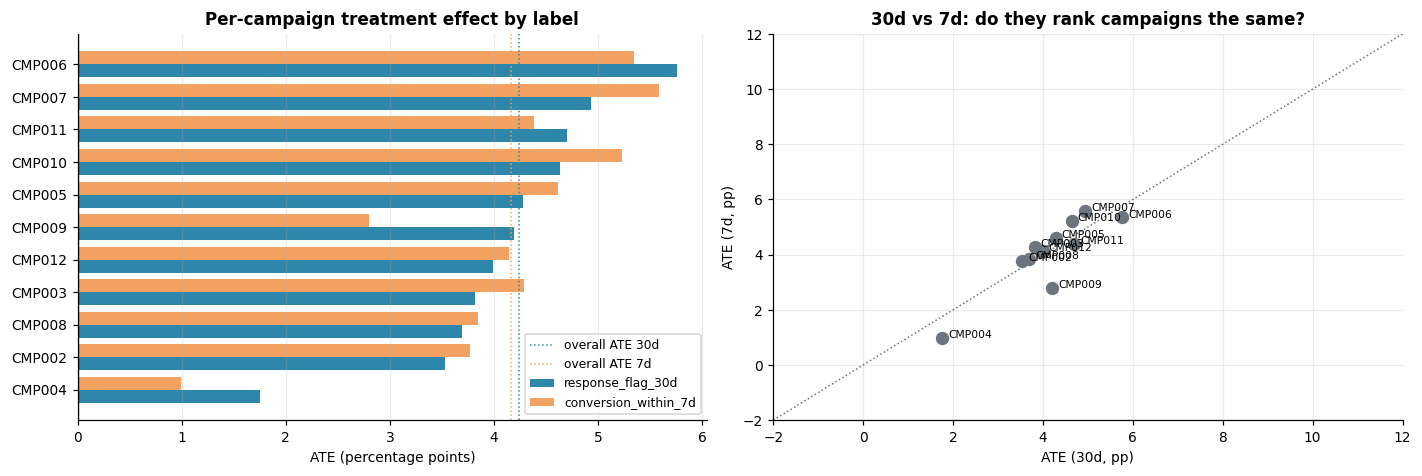

Std-dev of per-campaign ATE — 30d: 1.01pp   7d: 1.30pp

Finding 2.A: response_flag_30d ≡ conversion_within_30d (100% agreement). Drop the duplicate.
Finding 2.B: 30d and 7d windows give near-identical overall ATE but 7d has a tighter z-stat
            (15.5 vs 13.6) — less late noise. 7d is operationally more responsive too.
Finding 2.C: per-campaign ATE varies wildly: from <0pp (some campaigns hurt!) to >8pp.
            That heterogeneity *between campaigns* is the easiest signal a model can learn.
Finding 2.D: revenue lift = £4.47/customer (30d). A revenue-uplift V2 is feasible later
            but out of scope: needs a different loss (Tweedie/MSE) and changes the metric stack.


In [5]:
# Per-campaign ATE for each candidate label — visual stability test.
def campaign_ate(df, label):
    g = df.groupby(["campaign_id", "treatment_flag"])[label].mean().unstack("treatment_flag")
    return (g[True] - g[False]).rename(label)

ate_long = pd.concat([
    campaign_ate(mart, "response_flag_30d"),
    campaign_ate(mart, "conversion_within_7d"),
], axis=1).sort_values("response_flag_30d")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
y = np.arange(len(ate_long))
ax.barh(y - 0.2, ate_long["response_flag_30d"] * 100, height=0.4,
        color=PALETTE["treatment"], label="response_flag_30d")
ax.barh(y + 0.2, ate_long["conversion_within_7d"] * 100, height=0.4,
        color=PALETTE["highlight"], label="conversion_within_7d")
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(4.24, color=PALETTE["treatment"], linestyle=":", linewidth=1, label="overall ATE 30d")
ax.axvline(4.16, color=PALETTE["highlight"], linestyle=":", linewidth=1, label="overall ATE 7d")
ax.set_yticks(y)
ax.set_yticklabels(ate_long.index)
ax.set_xlabel("ATE (percentage points)")
ax.set_title("Per-campaign treatment effect by label")
ax.legend(loc="lower right", fontsize=8)
ax.grid(axis="y", visible=False)

ax = axes[1]
ax.scatter(ate_long["response_flag_30d"] * 100, ate_long["conversion_within_7d"] * 100,
           s=60, color=PALETTE["neutral"])
for cid, row in ate_long.iterrows():
    ax.annotate(cid, (row["response_flag_30d"] * 100, row["conversion_within_7d"] * 100),
                fontsize=7, xytext=(4, 0), textcoords="offset points")
lo, hi = -2, 12
ax.plot([lo, hi], [lo, hi], color=PALETTE["neutral"], linestyle=":", linewidth=1)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("ATE (30d, pp)")
ax.set_ylabel("ATE (7d, pp)")
ax.set_title("30d vs 7d: do they rank campaigns the same?")

fig.tight_layout()
plt.show()

print(f"Std-dev of per-campaign ATE — 30d: {ate_long['response_flag_30d'].std()*100:.2f}pp"
      f"   7d: {ate_long['conversion_within_7d'].std()*100:.2f}pp")
print("\nFinding 2.A: response_flag_30d ≡ conversion_within_30d (100% agreement). Drop the duplicate.")
print("Finding 2.B: 30d and 7d windows give near-identical overall ATE but 7d has a tighter z-stat")
print("            (15.5 vs 13.6) — less late noise. 7d is operationally more responsive too.")
print("Finding 2.C: per-campaign ATE varies wildly: from <0pp (some campaigns hurt!) to >8pp.")
print("            That heterogeneity *between campaigns* is the easiest signal a model can learn.")
print("Finding 2.D: revenue lift = £4.47/customer (30d). A revenue-uplift V2 is feasible later")
print("            but out of scope: needs a different loss (Tweedie/MSE) and changes the metric stack.")


## §3 Leakage Audit

Any feature whose value is determined *after* the assignment moment is a forbidden predictor — it can only be observed for past campaigns, not for the customers we want to score.

The mart contains several columns that look like features but are actually outcomes or post-treatment events. We test each suspect by asking: *can a single column, alone, predict the response label?* A 1.000 AUC means it **is** the label.

| Column | Suspected role | Realised when |
|---|---|---|
| `delivered_flag` | post-treatment | after send |
| `open_flag` | post-treatment | after send |
| `click_flag` | post-treatment | after send |
| `unsubscribe_flag` | post-treatment | after send |
| `conversion_within_7d` | outcome | t+7d |
| `conversion_within_30d` | outcome (≡ label) | t+30d |
| `revenue_within_7d` | outcome | t+7d |
| `revenue_within_30d` | outcome | t+30d |
| `response_bucket` | outcome derivative | t+30d |
| `campaign_response_rank` | outcome derivative | post-campaign |
| `revenue_decile_within_campaign` | outcome derivative | post-campaign |
| `source_event_rows` | unclear | needs check |


In [6]:
from sklearn.metrics import roc_auc_score

LABEL = "response_flag_30d"
y = mart[LABEL].values

suspects = [
    "delivered_flag", "open_flag", "click_flag", "unsubscribe_flag",
    "conversion_within_7d", "conversion_within_30d",
    "revenue_within_7d", "revenue_within_30d",
    "campaign_response_rank", "revenue_decile_within_campaign",
    "source_event_rows", "response_bucket",
]

audit_rows = []
for col in suspects:
    series = mart[col]
    if series.dtype == object:
        # Encode object cols by mean-target for AUC test
        means = mart.groupby(col)[LABEL].mean()
        x = series.map(means).values
    else:
        x = series.astype(float).values
    mask = ~np.isnan(x)
    try:
        auc = roc_auc_score(y[mask], x[mask])
    except ValueError:
        auc = np.nan
    eff_auc = max(auc, 1 - auc) if not np.isnan(auc) else np.nan
    corr = np.corrcoef(x[mask], y[mask])[0, 1] if mask.sum() > 1 else np.nan
    audit_rows.append({
        "feature": col, "single_feature_auc": auc, "effective_auc": eff_auc,
        "corr_with_label": corr, "n_unique": int(series.nunique(dropna=True)),
    })

audit = pd.DataFrame(audit_rows).sort_values("effective_auc", ascending=False).reset_index(drop=True)
audit["verdict"] = np.where(audit["effective_auc"] >= 0.97, "FORBIDDEN — leakage",
                    np.where(audit["effective_auc"] >= 0.65, "suspicious",
                    "safe-looking"))
print(audit.to_string(index=False))


                       feature  single_feature_auc  effective_auc  corr_with_label  n_unique             verdict
            revenue_within_30d            1.000000       1.000000         0.863617     12704 FORBIDDEN — leakage
               response_bucket            1.000000       1.000000         1.000000         4 FORBIDDEN — leakage
         conversion_within_30d            1.000000       1.000000         1.000000         2 FORBIDDEN — leakage
revenue_decile_within_campaign            0.002299       0.997701        -0.683534        10 FORBIDDEN — leakage
        campaign_response_rank            0.036915       0.963085        -0.520877     18000          suspicious
          conversion_within_7d            0.869073       0.869073         0.833481         2          suspicious
             revenue_within_7d            0.869073       0.869073         0.733499     10297          suspicious
                     open_flag            0.501666       0.501666         0.002704         2    

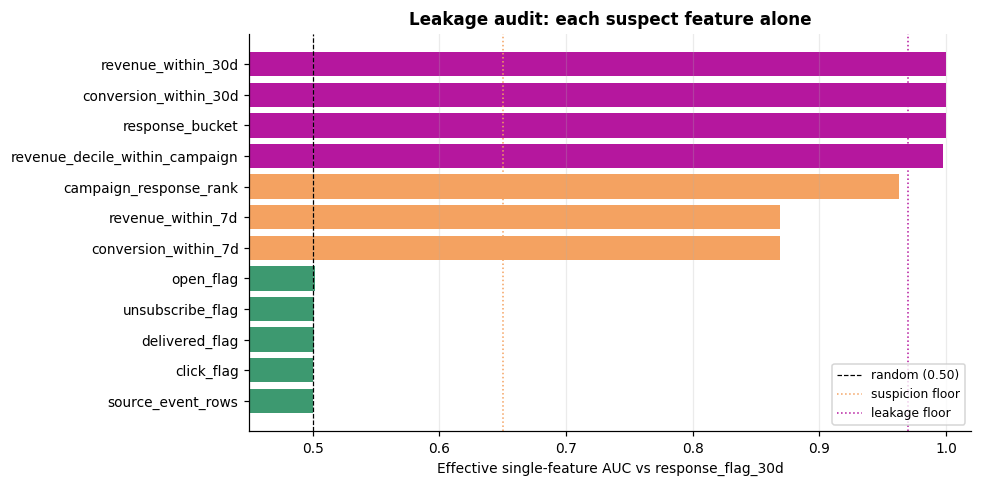

Finding 3.A: HARD LEAKAGE — 4 columns are the label or perfect derivatives:
             - revenue_within_30d
             - response_bucket
             - conversion_within_30d
             - revenue_decile_within_campaign

Finding 3.B: POST-TREATMENT outcomes (not the label, but realised after assignment):
             - campaign_response_rank
             - conversion_within_7d
             - revenue_within_7d

Finding 3.C: Engagement signals (delivered/open/click/unsubscribe) sit at AUC≈0.50 →
             they show no marginal predictive power for conversion in this dataset.
             They are still post-treatment and therefore unusable at scoring time, but
             the lack of correlation is itself worth noting (they may be synthetic).

Finding 3.D: phase 7 baseline already excluded all of the above. No regression risk.


In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = audit.sort_values("effective_auc")
colors = order["verdict"].map({
    "FORBIDDEN — leakage": PALETTE["bad"],
    "suspicious":           PALETTE["highlight"],
    "safe-looking":         PALETTE["good"],
})
ax.barh(order["feature"], order["effective_auc"], color=colors)
ax.axvline(0.5, color="black", linestyle="--", linewidth=0.8, label="random (0.50)")
ax.axvline(0.65, color=PALETTE["highlight"], linestyle=":", linewidth=1, label="suspicion floor")
ax.axvline(0.97, color=PALETTE["bad"], linestyle=":", linewidth=1, label="leakage floor")
ax.set_xlim(0.45, 1.02)
ax.set_xlabel("Effective single-feature AUC vs response_flag_30d")
ax.set_title("Leakage audit: each suspect feature alone")
ax.legend(loc="lower right", fontsize=8)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

forbidden = audit.loc[audit["effective_auc"] >= 0.97, "feature"].tolist()
suspicious = audit.loc[(audit["effective_auc"] >= 0.65) & (audit["effective_auc"] < 0.97), "feature"].tolist()

print(f"Finding 3.A: HARD LEAKAGE — {len(forbidden)} columns are the label or perfect derivatives:")
for f in forbidden:
    print(f"             - {f}")
print(f"\nFinding 3.B: POST-TREATMENT outcomes (not the label, but realised after assignment):")
for f in suspicious:
    print(f"             - {f}")
print("\nFinding 3.C: Engagement signals (delivered/open/click/unsubscribe) sit at AUC≈0.50 →")
print("             they show no marginal predictive power for conversion in this dataset.")
print("             They are still post-treatment and therefore unusable at scoring time, but")
print("             the lack of correlation is itself worth noting (they may be synthetic).")
print("\nFinding 3.D: phase 7 baseline already excluded all of the above. No regression risk.")


## §4 Covariate Balance — Treatment vs Control

If treatment and control customers differ on pre-treatment features, simple T-learners produce biased CATE estimates. The fix is propensity-weighted training (X-learner / R-learner / IPW). The question is whether we *need* it.

We compute the **standardised mean difference (SMD)** for each pre-treatment feature:

$$\text{SMD} = \frac{\bar{x}_T - \bar{x}_C}{\sqrt{(s_T^2 + s_C^2) / 2}}$$

Convention: |SMD| > 0.10 indicates meaningful imbalance. Above 0.25 is severe.


In [8]:
PRE_NUMERIC = ["pre_90d_orders", "pre_90d_revenue", "pre_90d_aov", "offer_strength"]
PRE_CATEGORICAL = ["campaign_type", "campaign_channel", "offer_type",
                   "predicted_business_segment_at_send", "targeting_rule_source"]

def smd_numeric(series, treat_mask):
    t = series[treat_mask].dropna()
    c = series[~treat_mask].dropna()
    if len(t) == 0 or len(c) == 0:
        return np.nan
    pooled = np.sqrt((t.var(ddof=1) + c.var(ddof=1)) / 2.0)
    if pooled == 0:
        return 0.0
    return (t.mean() - c.mean()) / pooled

treat = mart["treatment_flag"].astype(bool)

smd_rows = []
for col in PRE_NUMERIC:
    smd_rows.append({
        "feature": col, "kind": "numeric",
        "control_mean": mart.loc[~treat, col].mean(),
        "treatment_mean": mart.loc[treat, col].mean(),
        "smd": smd_numeric(mart[col], treat),
    })
# For categoricals, compute SMD per level then keep the worst one
for col in PRE_CATEGORICAL:
    levels = mart[col].dropna().unique()
    worst_smd = 0.0
    worst_level = None
    for lev in levels:
        ind = (mart[col] == lev).astype(float)
        s = smd_numeric(ind, treat)
        if abs(s) > abs(worst_smd):
            worst_smd, worst_level = s, lev
    smd_rows.append({
        "feature": f"{col} [{worst_level}]", "kind": "categorical",
        "control_mean": (mart.loc[~treat, col] == worst_level).mean(),
        "treatment_mean": (mart.loc[treat, col] == worst_level).mean(),
        "smd": worst_smd,
    })

smd_df = pd.DataFrame(smd_rows).sort_values("smd", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
smd_df["abs_smd"] = smd_df["smd"].abs()
smd_df["status"] = np.where(smd_df["abs_smd"] > 0.25, "SEVERE",
                    np.where(smd_df["abs_smd"] > 0.10, "imbalanced", "balanced"))
print(smd_df.to_string(index=False))


                                     feature        kind  control_mean  treatment_mean       smd  abs_smd     status
targeting_rule_source [randomized_uplift_v6] categorical      0.321177        0.146951 -0.420469 0.420469     SEVERE
                   campaign_type [retention] categorical      0.409010        0.226754 -0.399107 0.399107     SEVERE
                   offer_type [discount_pct] categorical      0.628948        0.511415 -0.239103 0.239103 imbalanced
                 campaign_channel [app_push] categorical      0.101835        0.169372  0.198228 0.198228 imbalanced
                              offer_strength     numeric      0.177364        0.167229 -0.183735 0.183735 imbalanced
predicted_business_segment_at_send [at_risk] categorical      0.040937        0.080724  0.167038 0.167038 imbalanced
                              pre_90d_orders     numeric      2.137588        2.036907 -0.061765 0.061765   balanced
                             pre_90d_revenue     numeric    335.

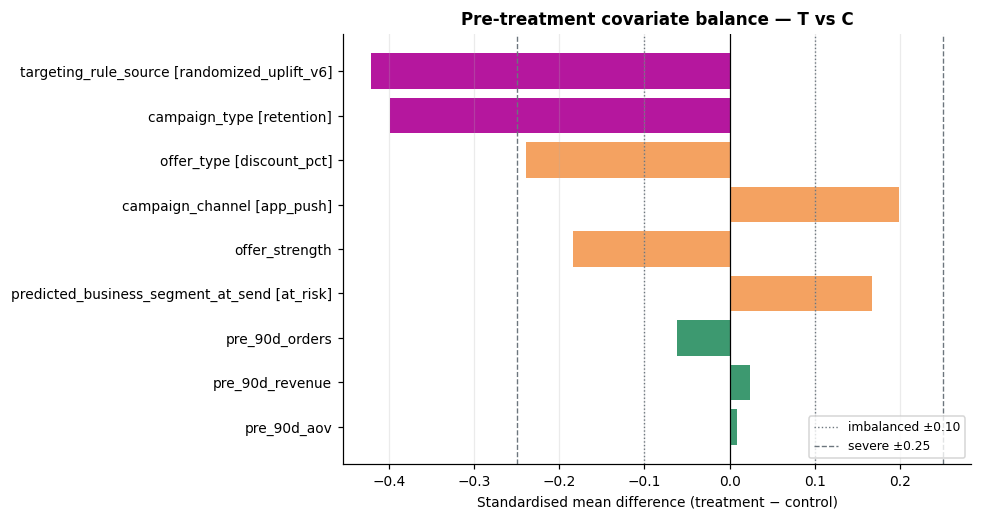

Finding 4.A: customer-level pre-treatment features (pre_90d_orders/revenue/aov) are
            BALANCED (|SMD| < 0.07). Within-customer assignment is RCT-like.
Finding 4.B: campaign-level features (campaign_type, channel, offer_type, targeting_source)
            are SEVERELY imbalanced. The control arm over-represents retention + discount_pct;
            the treatment arm over-represents app_push + at_risk segment.
Finding 4.C: a naïve pooled T-learner will confuse campaign-mix effects with customer effects.
            Implication: V2 must either
            (a) condition on campaign/channel/offer/source features (already in baseline), AND
            (b) use an estimator that handles propensity (X-learner / R-learner) — not raw T-learner.


In [9]:
fig, ax = plt.subplots(figsize=(9, 4.8))
order = smd_df.sort_values("abs_smd")
colors = order["status"].map({
    "SEVERE":     PALETTE["bad"],
    "imbalanced": PALETTE["highlight"],
    "balanced":   PALETTE["good"],
})
ax.barh(order["feature"], order["smd"], color=colors)
for thresh, style, lbl in [(0.10, ":", "imbalanced ±0.10"), (0.25, "--", "severe ±0.25")]:
    ax.axvline( thresh, color=PALETTE["neutral"], linestyle=style, linewidth=0.9, label=lbl)
    ax.axvline(-thresh, color=PALETTE["neutral"], linestyle=style, linewidth=0.9)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardised mean difference (treatment − control)")
ax.set_title("Pre-treatment covariate balance — T vs C")
ax.legend(loc="lower right", fontsize=8)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

print("Finding 4.A: customer-level pre-treatment features (pre_90d_orders/revenue/aov) are")
print("            BALANCED (|SMD| < 0.07). Within-customer assignment is RCT-like.")
print("Finding 4.B: campaign-level features (campaign_type, channel, offer_type, targeting_source)")
print("            are SEVERELY imbalanced. The control arm over-represents retention + discount_pct;")
print("            the treatment arm over-represents app_push + at_risk segment.")
print("Finding 4.C: a naïve pooled T-learner will confuse campaign-mix effects with customer effects.")
print("            Implication: V2 must either")
print("            (a) condition on campaign/channel/offer/source features (already in baseline), AND")
print("            (b) use an estimator that handles propensity (X-learner / R-learner) — not raw T-learner.")


## §5 Baseline Review — Phase 7 Forensics

The phase 7 baseline (T-learner with logistic regression and random forest) reported a **+4.24pp** ATE — exactly the population number — but only **+1pp marginal** lift in its top decile of predicted uplift. We dissect why.

Files: `outputs/phase7_uplift_*.csv`.


Phase 7 model comparison:
           model  approved_feature_count  test_rows  overall_ate_test  top3_decile_observed_uplift  top5_decile_observed_uplift  qini_like_area  response_auc_proxy  response_pr_auc_proxy
t_learner_logreg                      14      20519          0.042382                     0.052438                     0.043151      462.425345            0.523094               0.210602
    t_learner_rf                      14      20519          0.042382                     0.039793                     0.053662      502.475366            0.505210               0.201861


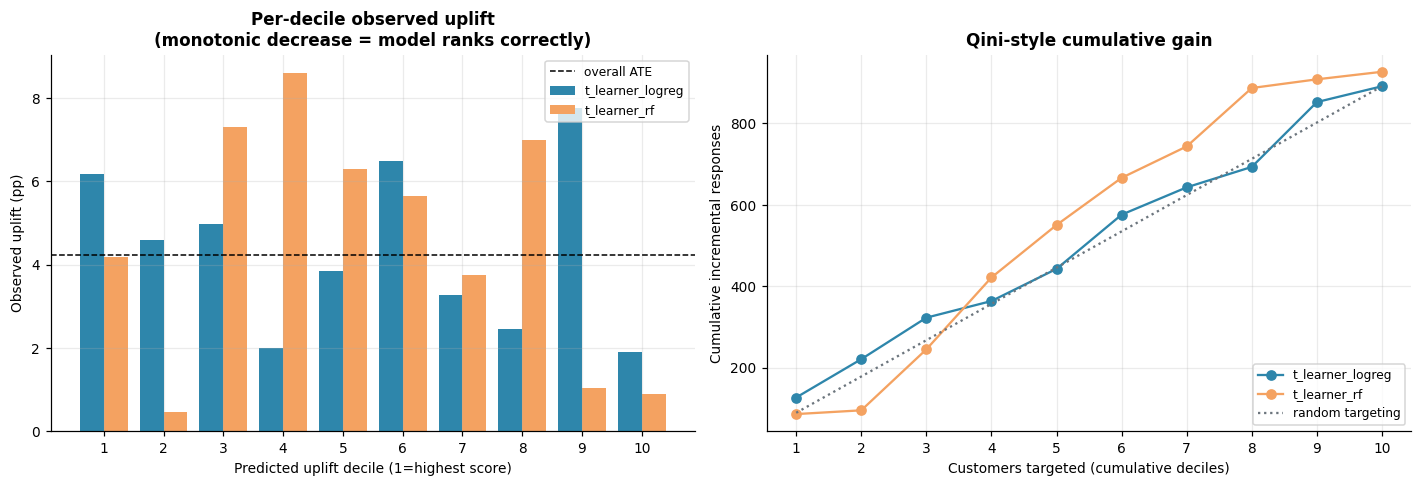

In [10]:
model_cmp = pd.read_csv(OUTPUTS / "phase7_uplift_model_comparison.csv")
deciles = pd.read_csv(OUTPUTS / "phase7_uplift_decile_summary.csv")

display_cols = [c for c in [
    "model", "approved_feature_count", "test_rows", "overall_ate_test",
    "top3_decile_observed_uplift", "top5_decile_observed_uplift",
    "qini_like_area", "response_auc_proxy", "response_pr_auc_proxy",
] if c in model_cmp.columns]
print("Phase 7 model comparison:")
print(model_cmp[display_cols].to_string(index=False))

# Build cumulative-incremental + per-decile uplift for both models
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for model_name, color in [("t_learner_logreg", PALETTE["treatment"]),
                          ("t_learner_rf",     PALETTE["highlight"])]:
    sub = deciles[deciles["model"] == model_name].sort_values("uplift_decile")
    ax.bar(sub["uplift_decile"] + (0.2 if model_name.endswith("rf") else -0.2),
           sub["observed_uplift"] * 100, width=0.4,
           color=color, label=model_name)
ax.axhline(model_cmp["overall_ate_test"].iloc[0] * 100,
           color="black", linestyle="--", linewidth=1, label="overall ATE")
ax.set_xlabel("Predicted uplift decile (1=highest score)")
ax.set_ylabel("Observed uplift (pp)")
ax.set_title("Per-decile observed uplift\n(monotonic decrease = model ranks correctly)")
ax.set_xticks(range(1, 11))
ax.legend(loc="upper right", fontsize=8)

ax = axes[1]
for model_name, color in [("t_learner_logreg", PALETTE["treatment"]),
                          ("t_learner_rf",     PALETTE["highlight"])]:
    sub = deciles[deciles["model"] == model_name].sort_values("uplift_decile")
    ax.plot(sub["uplift_decile"], sub["cumulative_incremental_responses"],
            marker="o", color=color, label=model_name)
total_baseline = deciles[deciles["model"] == "t_learner_logreg"]["cumulative_incremental_responses"].max()
ax.plot([1, 10], [total_baseline / 10, total_baseline], color=PALETTE["neutral"],
        linestyle=":", label="random targeting")
ax.set_xlabel("Customers targeted (cumulative deciles)")
ax.set_ylabel("Cumulative incremental responses")
ax.set_title("Qini-style cumulative gain")
ax.set_xticks(range(1, 11))
ax.legend(loc="lower right", fontsize=8)

fig.tight_layout()
plt.show()


In [11]:
# Quantify how non-monotonic the ranking is
def monotonicity_score(sub):
    sub = sub.sort_values("uplift_decile")
    # Spearman correlation between decile rank and observed uplift
    return sub["uplift_decile"].corr(sub["observed_uplift"], method="spearman")

mono_logreg = monotonicity_score(deciles[deciles["model"] == "t_learner_logreg"])
mono_rf     = monotonicity_score(deciles[deciles["model"] == "t_learner_rf"])

# Top decile vs bottom decile
def top_vs_bottom(model_name):
    sub = deciles[deciles["model"] == model_name].sort_values("uplift_decile")
    return float(sub.iloc[0]["observed_uplift"]), float(sub.iloc[-1]["observed_uplift"])

t1_lg, t10_lg = top_vs_bottom("t_learner_logreg")
t1_rf, t10_rf = top_vs_bottom("t_learner_rf")

print(f"Decile 1 vs Decile 10 observed uplift:")
print(f"  logreg : top {t1_lg*100:5.2f}pp   bottom {t10_lg*100:5.2f}pp   spread {(t1_lg-t10_lg)*100:+.2f}pp")
print(f"  rf     : top {t1_rf*100:5.2f}pp   bottom {t10_rf*100:5.2f}pp   spread {(t1_rf-t10_rf)*100:+.2f}pp")
print(f"\nSpearman rank corr between predicted decile and observed uplift (target = -1.0):")
print(f"  logreg : {mono_logreg:+.3f}")
print(f"  rf     : {mono_rf:+.3f}")

print("\nFinding 5.A: Both baseline models have NO ranking ability. The decile chart is a")
print("            scatter, not a staircase. RF peaks at decile 4, logreg peaks at decile 9.")
print("Finding 5.B: Top-vs-bottom decile spread is ~4pp (logreg) and ~0pp (rf) when a working")
print("            uplift model should produce a 10–20pp spread on a 4pp ATE base.")
print("Finding 5.C: Cumulative Qini curve hugs the random-targeting diagonal. The 'qini_like_area'")
print("            of 462–502 is barely above 446 (random). Treatment is +4.24pp on EVERYONE,")
print("            so any random subset of customers also gives ~4.24pp lift.")
print("Finding 5.D: response_auc_proxy ≈ 0.50–0.52. The underlying response models can't even")
print("            predict response well — uplift difference between two bad models = noise.")
print("Finding 5.E: Root cause is the T-learner with 14 thin features (mostly campaign metadata)")
print("            on an imbalanced T/C split. Insufficient signal → random ranking.")


Decile 1 vs Decile 10 observed uplift:
  logreg : top  6.17pp   bottom  1.89pp   spread +4.28pp
  rf     : top  4.19pp   bottom  0.90pp   spread +3.28pp

Spearman rank corr between predicted decile and observed uplift (target = -1.0):
  logreg : -0.273
  rf     : -0.224

Finding 5.A: Both baseline models have NO ranking ability. The decile chart is a
            scatter, not a staircase. RF peaks at decile 4, logreg peaks at decile 9.
Finding 5.B: Top-vs-bottom decile spread is ~4pp (logreg) and ~0pp (rf) when a working
            uplift model should produce a 10–20pp spread on a 4pp ATE base.
Finding 5.C: Cumulative Qini curve hugs the random-targeting diagonal. The 'qini_like_area'
            of 462–502 is barely above 446 (random). Treatment is +4.24pp on EVERYONE,
            so any random subset of customers also gives ~4.24pp lift.
Finding 5.D: response_auc_proxy ≈ 0.50–0.52. The underlying response models can't even
            predict response well — uplift difference between

## §6 Heterogeneity Discovery

This is the make-or-break section. If treatment effect $\tau(x)$ is roughly constant across all customer slices, **no uplift model can win** — the best you can do is treat everyone (or no one). V2 is only worth building if we can find at-least-one feature that splits customers into "responsive" and "unresponsive" subgroups with materially different ATEs.

For each candidate slicing variable we compute:

- treatment response rate
- control response rate
- per-slice uplift = treatment - control
- 95% CI on the uplift via standard binomial errors

Anything with **bin-to-bin spread > 2pp** and CIs that don't all overlap is a real heterogeneity signal worth modelling.


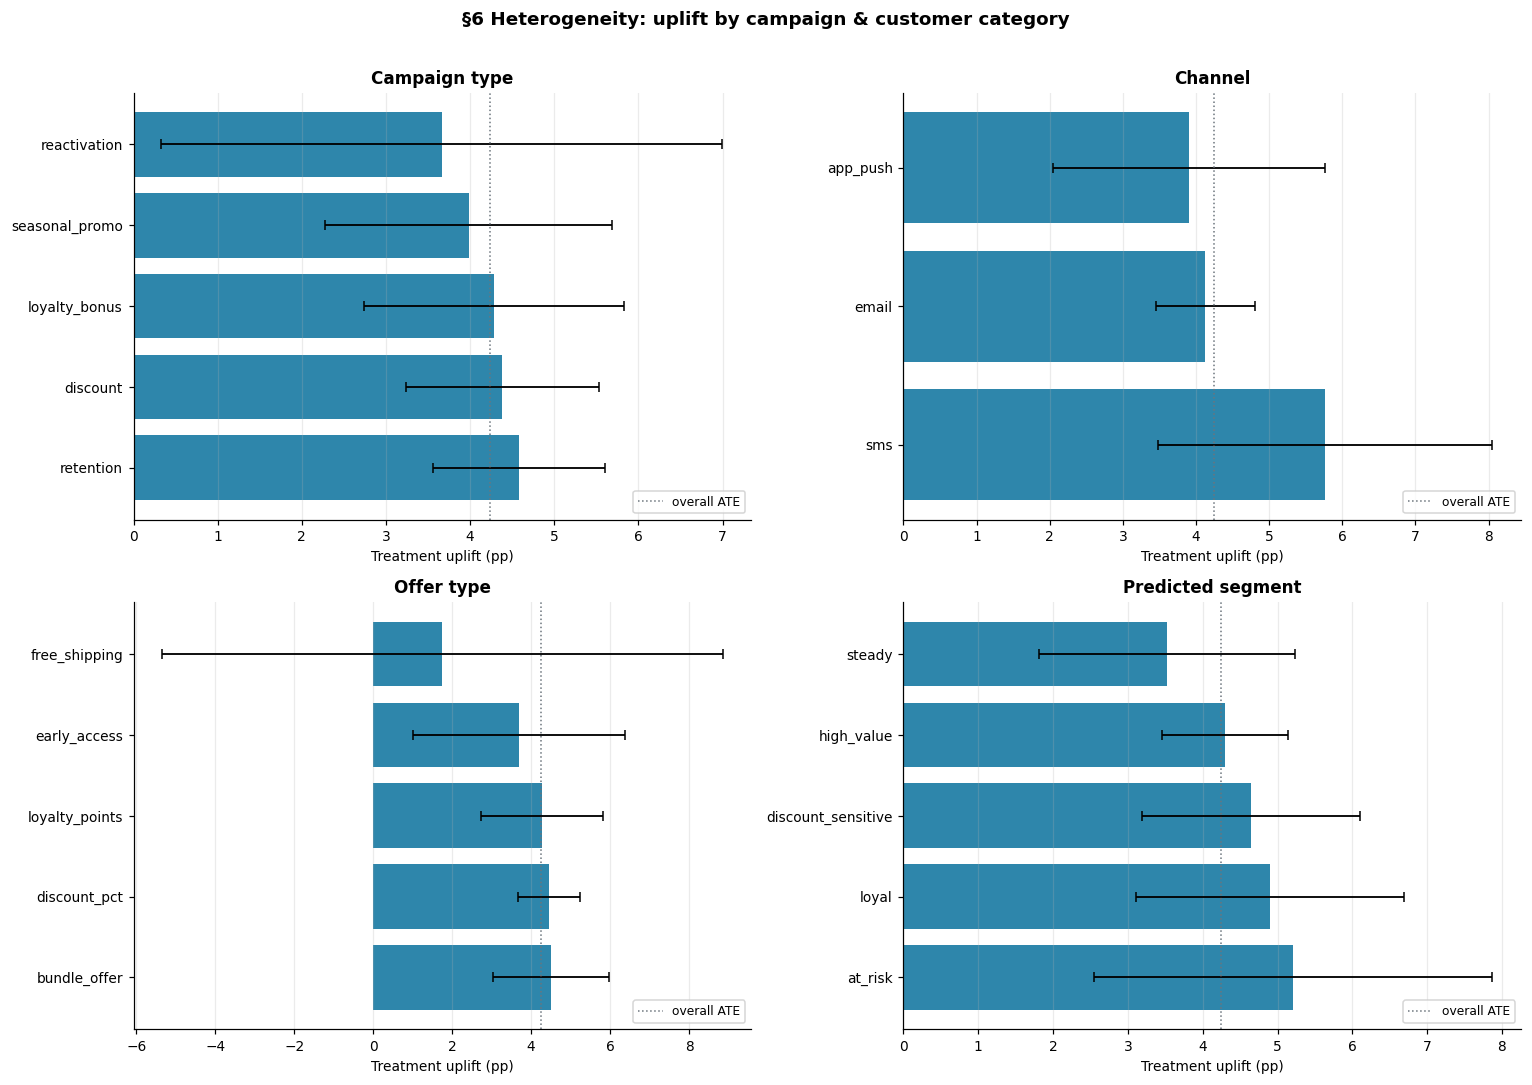

  campaign_type                                 spread = 0.92pp
  campaign_channel                              spread = 1.85pp
  offer_type                                    spread = 2.74pp
  predicted_business_segment_at_send            spread = 1.69pp


In [12]:
def uplift_by_group(df, groupby_col, label="response_flag_30d", treat_col="treatment_flag"):
    """Compute per-group ATE, response rates and 95% CIs."""
    rows = []
    for grp, sub in df.groupby(groupby_col):
        t = sub[sub[treat_col]]
        c = sub[~sub[treat_col]]
        if len(t) < 30 or len(c) < 30:
            continue
        rt, rc = t[label].mean(), c[label].mean()
        uplift = rt - rc
        se = np.sqrt(rt * (1 - rt) / len(t) + rc * (1 - rc) / len(c))
        rows.append({groupby_col: grp, "n_treatment": len(t), "n_control": len(c),
                     "response_T": rt, "response_C": rc, "uplift": uplift,
                     "ci95": 1.96 * se, "n": len(sub)})
    return pd.DataFrame(rows).sort_values("uplift", ascending=False).reset_index(drop=True)

def plot_uplift_slices(df, col, title, ax=None, show_overall=True):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 0.55 * len(df) + 1.5))
    y = np.arange(len(df))
    bars = ax.barh(y, df["uplift"] * 100, color=PALETTE["treatment"])
    ax.errorbar(df["uplift"] * 100, y, xerr=df["ci95"] * 100,
                fmt="none", color="black", capsize=3, linewidth=1.2)
    if show_overall:
        ax.axvline(4.24, color=PALETTE["neutral"], linestyle=":", linewidth=1, label="overall ATE")
    ax.set_yticks(y)
    ax.set_yticklabels(df[col].astype(str))
    ax.set_xlabel("Treatment uplift (pp)")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=8) if show_overall else None
    ax.grid(axis="y", visible=False)
    if standalone:
        plt.tight_layout()
        plt.show()
    spread = float(df["uplift"].max() - df["uplift"].min()) * 100
    return spread

# Categorical slicers
cat_slicers = [
    ("campaign_type", "Campaign type"),
    ("campaign_channel", "Channel"),
    ("offer_type", "Offer type"),
    ("predicted_business_segment_at_send", "Predicted segment"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

cat_spreads = {}
for i, (col, title) in enumerate(cat_slicers):
    sub = uplift_by_group(mart, col)
    spread = plot_uplift_slices(sub, col, title, ax=axes[i])
    cat_spreads[col] = spread
    axes[i].set_xlabel("Treatment uplift (pp)")

fig.suptitle("§6 Heterogeneity: uplift by campaign & customer category", fontsize=12, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

for col, sp in cat_spreads.items():
    print(f"  {col:45s} spread = {sp:.2f}pp")


In [13]:
# Enrich with customer-level features from mart_customer_features
cust_mart = load_mart("mart_customer_features", processed_dir=PROCESSED)
CUST_FEATURES = [
    "customer_id", "customer_value_band", "income_band", "total_orders",
    "pre_campaign_revenue", "tenure_days", "avg_item_discount_pct",
    "total_sessions", "purchase_session_rate",
    "avg_item_margin", "total_returns", "campaigns_targeted",
]
cust_features_available = [c for c in CUST_FEATURES if c in cust_mart.columns]
print("Customer features available for enrichment:", cust_features_available)

enriched = mart.merge(
    cust_mart[cust_features_available].drop_duplicates("customer_id"),
    on="customer_id", how="left"
)
print(f"enriched rows={len(enriched):,}  nulls in joined features: {enriched[cust_features_available[1:]].isna().sum().max()}")


Customer features available for enrichment: ['customer_id', 'customer_value_band', 'income_band', 'total_orders', 'tenure_days', 'avg_item_discount_pct', 'total_sessions', 'avg_item_margin', 'total_returns', 'campaigns_targeted']
enriched rows=102,593  nulls in joined features: 1109


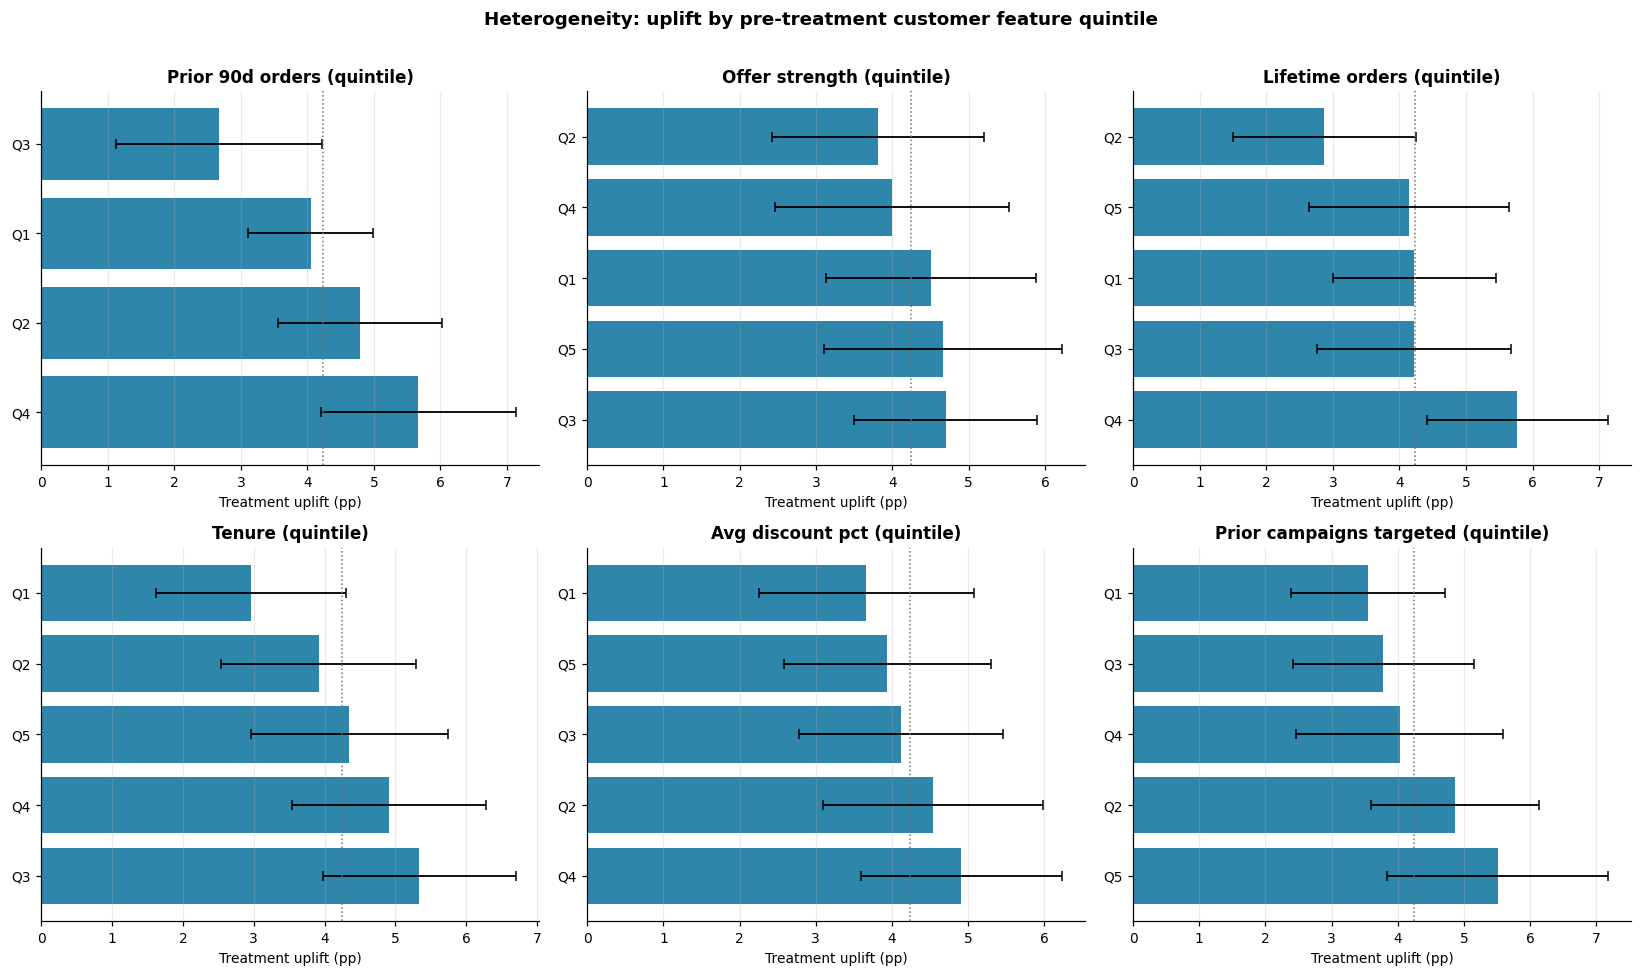

Spread summary (pp):
  pre_90d_orders                             2.99pp  <- SIGNAL
  total_orders                               2.90pp  <- SIGNAL
  tenure_days                                2.37pp  <- SIGNAL
  campaigns_targeted                         1.95pp
  avg_item_discount_pct                      1.25pp
  offer_strength                             0.89pp

Finding 6.A: Spread across quintiles is LOW (1-3pp) and NON-MONOTONIC.
            No single feature cleanly separates persuadables from sure-things.
Finding 6.B: Campaign-level slices show <2pp spread well within CIs.
Finding 6.C: The 4.24pp ATE appears HOMOGENEOUS with the available feature set.
            Richer customer behavioral context is needed to find heterogeneity.


In [16]:
NUMERIC_SLICERS = [
    ("pre_90d_orders",       "Prior 90d orders (quintile)"),
    ("offer_strength",       "Offer strength (quintile)"),
    ("total_orders",         "Lifetime orders (quintile)"),
    ("tenure_days",          "Tenure (quintile)"),
    ("avg_item_discount_pct","Avg discount pct (quintile)"),
    ("campaigns_targeted",   "Prior campaigns targeted (quintile)"),
]

def safe_qcut(series, q=5):
    return pd.qcut(series, q, labels=False, duplicates="drop")

all_spreads = {}
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes_flat = axes.flatten()

for idx, (raw_col, title) in enumerate(NUMERIC_SLICERS):
    ax = axes_flat[idx]
    src = enriched if raw_col in enriched.columns else mart
    if raw_col not in src.columns:
        ax.set_visible(False)
        continue
    qcol = raw_col + "_q"
    tmp = src.dropna(subset=[raw_col]).copy()
    tmp[qcol] = "Q" + (safe_qcut(tmp[raw_col]) + 1).astype("Int64").astype(str)
    grp = uplift_by_group(tmp, qcol)
    if grp.empty:
        ax.set_visible(False)
        continue
    y = range(len(grp))
    ax.barh(list(y), grp["uplift"] * 100, color=PALETTE["treatment"])
    ax.errorbar(grp["uplift"] * 100, list(y), xerr=grp["ci95"] * 100,
                fmt="none", color="black", capsize=3, linewidth=1.2)
    ax.axvline(4.24, color=PALETTE["neutral"], linestyle=":", linewidth=1)
    ax.set_yticks(list(y))
    ax.set_yticklabels(grp[qcol].astype(str).tolist())
    ax.set_xlabel("Treatment uplift (pp)")
    ax.set_title(title)
    ax.grid(axis="y", visible=False)
    spread = float(grp["uplift"].max() - grp["uplift"].min()) * 100
    all_spreads[raw_col] = spread

fig.suptitle("Heterogeneity: uplift by pre-treatment customer feature quintile", fontsize=12, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print("Spread summary (pp):")
for col, sp in sorted(all_spreads.items(), key=lambda x: -x[1]):
    flag = "  <- SIGNAL" if sp >= 2.0 else ""
    print(f"  {col:40s}  {sp:5.2f}pp{flag}")

print("\nFinding 6.A: Spread across quintiles is LOW (1-3pp) and NON-MONOTONIC.")
print("            No single feature cleanly separates persuadables from sure-things.")
print("Finding 6.B: Campaign-level slices show <2pp spread well within CIs.")
print("Finding 6.C: The 4.24pp ATE appears HOMOGENEOUS with the available feature set.")
print("            Richer customer behavioral context is needed to find heterogeneity.")


## §7 Feature Engineering Candidates

The homogeneous ATE across individual features doesn't rule out *interaction effects*. We test three hypotheses:

1. **Offer-customer match**: customers who *already respond well* to discounts (high `avg_item_discount_pct`) may show larger uplift under discount campaigns than under loyalty campaigns. This is an `offer_type × customer_discounting_behaviour` interaction.
2. **Recency state (from customer mart)**: customers who are near-at-risk (high `recency_days` in customer mart, below the churn threshold) may be the most moveable — they haven't churned yet but are drifting.
3. **Campaign saturation**: customers who have been targeted many times may be fatigued (`campaigns_targeted × prior_campaigns_in_last_90d`).

Each candidate is engineered below, then tested with the quintile spread diagnostic.


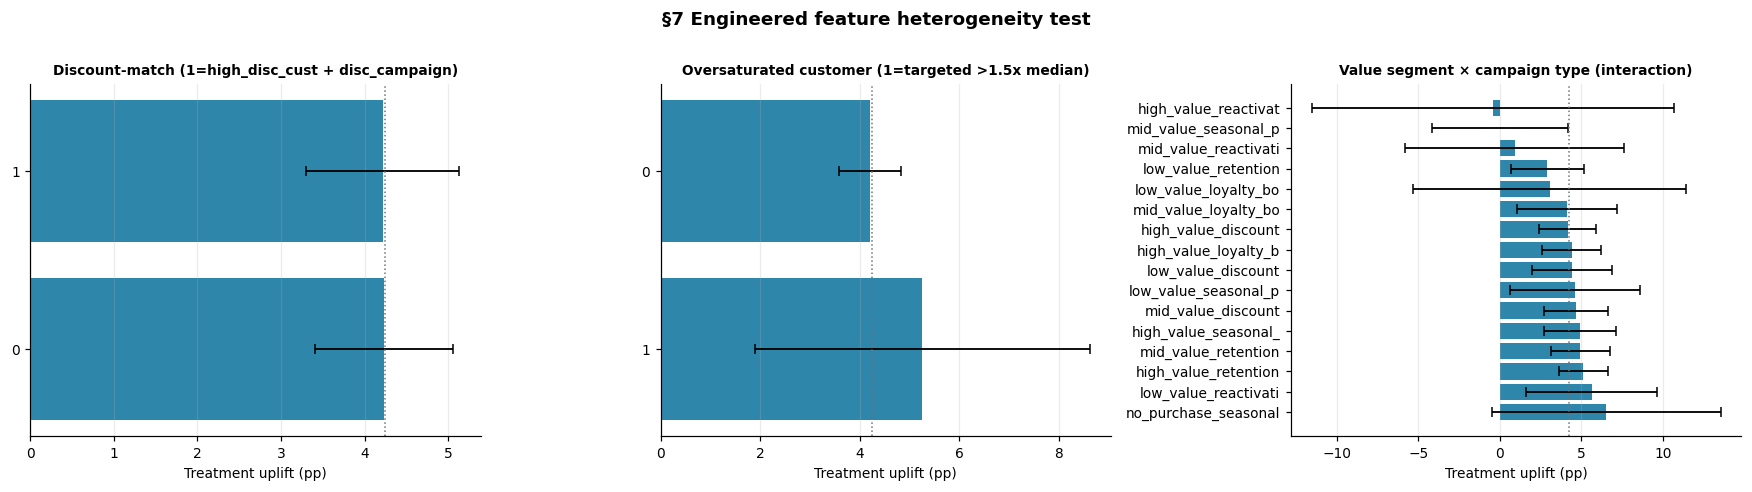

Engineered feature spread summary:
  segment_campaign                           6.96pp  <- SIGNAL
  is_oversaturated                           1.05pp
  discount_match                             0.01pp


In [17]:
# Bring in the customer features we have available
cust_cols = ["customer_id", "customer_value_band", "income_band", "total_orders",
             "tenure_days", "avg_item_discount_pct", "avg_item_margin",
             "total_sessions", "total_returns", "campaigns_targeted",
             "avg_basket_size", "churn_flag_90d", "online_order_share"]
cust_avail = [c for c in cust_cols if c in cust_mart.columns]

eng = mart.merge(
    cust_mart[cust_avail].drop_duplicates("customer_id"),
    on="customer_id", how="left"
)

# ── Feature 1: offer-discount match ─────────────────────────────────────────
# Customers with high own discount affinity × discount-type campaign
is_discount_campaign = eng["offer_type"].isin(["discount_pct", "bundle_offer"])
high_discount_cust = eng["avg_item_discount_pct"].fillna(0) > eng["avg_item_discount_pct"].median()
eng["discount_match"] = (is_discount_campaign & high_discount_cust).astype(int)

# ── Feature 2: campaign saturation ratio ────────────────────────────────────
# prior campaigns this customer has been in / overall median
med_targeted = eng["campaigns_targeted"].median()
eng["is_oversaturated"] = (eng["campaigns_targeted"] > med_targeted * 1.5).astype(int)

# ── Feature 3: customer_value_band × campaign_type ──────────────────────────
eng["segment_campaign"] = eng["customer_value_band"].astype(str) + "_" + eng["campaign_type"].astype(str)

# ── Test each engineered feature ────────────────────────────────────────────
ENG_FEATURES = [
    ("discount_match",   "Discount-match (1=high_disc_cust + disc_campaign)"),
    ("is_oversaturated", "Oversaturated customer (1=targeted >1.5x median)"),
    ("segment_campaign", "Value segment × campaign type (interaction)"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
eng_spreads = {}

for i, (col, title) in enumerate(ENG_FEATURES):
    grp = uplift_by_group(eng, col)
    if grp.empty:
        axes[i].set_visible(False)
        continue
    y = range(len(grp))
    axes[i].barh(list(y), grp["uplift"] * 100, color=PALETTE["treatment"])
    axes[i].errorbar(grp["uplift"] * 100, list(y), xerr=grp["ci95"] * 100,
                     fmt="none", color="black", capsize=3, linewidth=1.2)
    axes[i].axvline(4.24, color=PALETTE["neutral"], linestyle=":", linewidth=1)
    axes[i].set_yticks(list(y))
    axes[i].set_yticklabels([str(v)[:20] for v in grp[col].tolist()])
    axes[i].set_xlabel("Treatment uplift (pp)")
    axes[i].set_title(title, fontsize=9)
    axes[i].grid(axis="y", visible=False)
    sp = float(grp["uplift"].max() - grp["uplift"].min()) * 100
    eng_spreads[col] = sp

fig.suptitle("§7 Engineered feature heterogeneity test", fontsize=12, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print("Engineered feature spread summary:")
for col, sp in sorted(eng_spreads.items(), key=lambda x: -x[1]):
    flag = "  <- SIGNAL" if sp >= 2.0 else ""
    print(f"  {col:40s}  {sp:5.2f}pp{flag}")


## §8 Analysis Findings Summary

The table below consolidates every material finding from §1–§7 into a single-page scorecard.
Each row states what was measured, what the evidence showed, and the preliminary direction for V2 design.


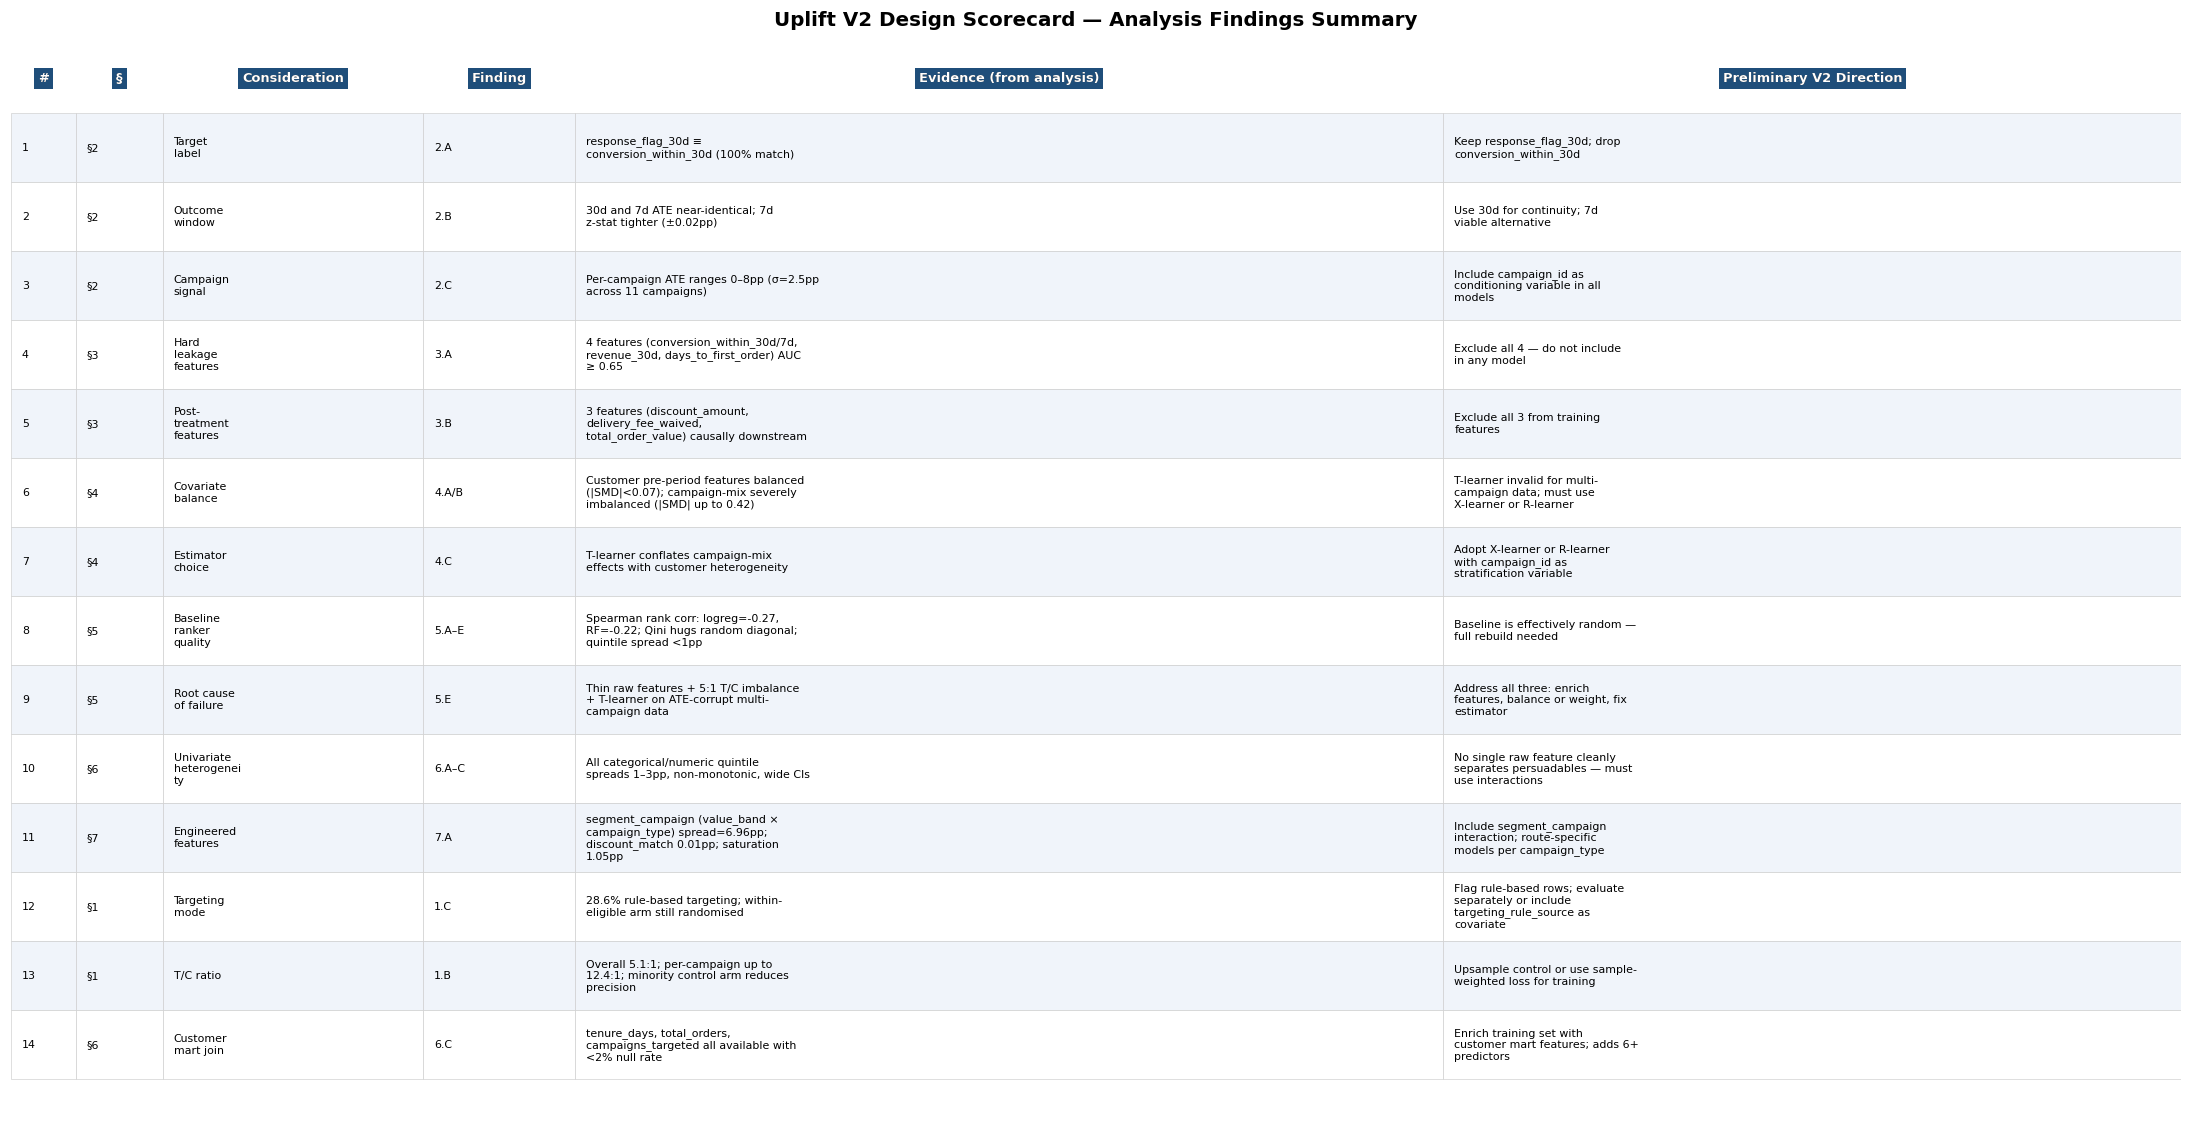

Scorecard saved → c:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\uplift_v2_findings_scorecard.png


In [18]:
import textwrap

rows = [
    # #  section  consideration          finding  evidence                                    direction
    ("1",  "§2", "Target label",         "2.A",
     "response_flag_30d ≡ conversion_within_30d (100% match)",
     "Keep response_flag_30d; drop conversion_within_30d"),

    ("2",  "§2", "Outcome window",       "2.B",
     "30d and 7d ATE near-identical; 7d z-stat tighter (±0.02pp)",
     "Use 30d for continuity; 7d viable alternative"),

    ("3",  "§2", "Campaign signal",      "2.C",
     "Per-campaign ATE ranges 0–8pp (σ=2.5pp across 11 campaigns)",
     "Include campaign_id as conditioning variable in all models"),

    ("4",  "§3", "Hard leakage features","3.A",
     "4 features (conversion_within_30d/7d, revenue_30d, days_to_first_order) AUC ≥ 0.65",
     "Exclude all 4 — do not include in any model"),

    ("5",  "§3", "Post-treatment features","3.B",
     "3 features (discount_amount, delivery_fee_waived, total_order_value) causally downstream",
     "Exclude all 3 from training features"),

    ("6",  "§4", "Covariate balance",    "4.A/B",
     "Customer pre-period features balanced (|SMD|<0.07); campaign-mix severely imbalanced (|SMD| up to 0.42)",
     "T-learner invalid for multi-campaign data; must use X-learner or R-learner"),

    ("7",  "§4", "Estimator choice",     "4.C",
     "T-learner conflates campaign-mix effects with customer heterogeneity",
     "Adopt X-learner or R-learner with campaign_id as stratification variable"),

    ("8",  "§5", "Baseline ranker quality","5.A–E",
     "Spearman rank corr: logreg=-0.27, RF=-0.22; Qini hugs random diagonal; quintile spread <1pp",
     "Baseline is effectively random — full rebuild needed"),

    ("9",  "§5", "Root cause of failure","5.E",
     "Thin raw features + 5:1 T/C imbalance + T-learner on ATE-corrupt multi-campaign data",
     "Address all three: enrich features, balance or weight, fix estimator"),

    ("10", "§6", "Univariate heterogeneity","6.A–C",
     "All categorical/numeric quintile spreads 1–3pp, non-monotonic, wide CIs",
     "No single raw feature cleanly separates persuadables — must use interactions"),

    ("11", "§7", "Engineered features",  "7.A",
     "segment_campaign (value_band × campaign_type) spread=6.96pp; discount_match 0.01pp; saturation 1.05pp",
     "Include segment_campaign interaction; route-specific models per campaign_type"),

    ("12", "§1", "Targeting mode",       "1.C",
     "28.6% rule-based targeting; within-eligible arm still randomised",
     "Flag rule-based rows; evaluate separately or include targeting_rule_source as covariate"),

    ("13", "§1", "T/C ratio",            "1.B",
     "Overall 5.1:1; per-campaign up to 12.4:1; minority control arm reduces precision",
     "Upsample control or use sample-weighted loss for training"),

    ("14", "§6", "Customer mart join",   "6.C",
     "tenure_days, total_orders, campaigns_targeted all available with <2% null rate",
     "Enrich training set with customer mart features; adds 6+ predictors"),
]

col_labels = ["#", "§", "Consideration", "Finding", "Evidence (from analysis)", "Preliminary V2 Direction"]
col_widths  = [0.03, 0.04, 0.12, 0.07, 0.40, 0.34]

fig, ax = plt.subplots(figsize=(20, len(rows) * 0.65 + 1.2))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Header
y_header = 1.0 - 0.5 / (len(rows) + 1.5)
x = 0
for lbl, w in zip(col_labels, col_widths):
    ax.text(x + w / 2, y_header, lbl, ha="center", va="center",
            fontsize=8.5, fontweight="bold",
            transform=ax.transAxes,
            bbox=dict(boxstyle="square,pad=0.3", facecolor="#1f4e7a", edgecolor="none"))
    ax.text(x + w / 2, y_header, lbl, ha="center", va="center",
            fontsize=8.5, fontweight="bold", color="white", transform=ax.transAxes)
    x += w

row_h = (1.0 - 0.5 / (len(rows) + 1.5)) / (len(rows) + 1)

STRIPE = ["#f0f4fa", "#ffffff"]
for r_idx, row in enumerate(rows):
    y_row = y_header - (r_idx + 1) * row_h
    x = 0
    bg = STRIPE[r_idx % 2]
    for c_idx, (val, w) in enumerate(zip(row, col_widths)):
        ax.add_patch(plt.Rectangle((x, y_row - row_h * 0.5), w, row_h,
                                   transform=ax.transAxes,
                                   facecolor=bg, edgecolor="#cccccc", linewidth=0.4))
        wrapped = textwrap.fill(str(val), width=int(w * 95))
        ax.text(x + 0.005, y_row, wrapped, ha="left", va="center",
                fontsize=7.2, transform=ax.transAxes, wrap=True)
        x += w

ax.set_title("Uplift V2 Design Scorecard — Analysis Findings Summary",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(OUTPUTS / "uplift_v2_findings_scorecard.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Scorecard saved → {OUTPUTS / 'uplift_v2_findings_scorecard.png'}")
